# 🟤 Chapter 6: Algorithm Chains and Pipelines
**Referensi:** *Introduction to Machine Learning with Python* (Andreas C. Müller & Sarah Guido)
---
> **Author:** Dhafi Dzakwan Pratama | 101032300213
> **Topik:** Menghindari Data Leakage dengan Pipeline
---
## 1. Masalah Kebocoran Data (Data Leakage)
Saat kita menggunakan `MinMaxScaler` sebelum melakukan `cross_val_score`, informasi dari data uji ikut masuk ke dalam perhitungan skala (karena kita melakukan fit scaler pada seluruh data uji dan latih sekaligus). Ini menyebabkan performa model terlihat bagus saat validasi, namun memburuk pada data nyata.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

%matplotlib inline

## 2. Membangun Pipeline
Untuk mengatasi masalah di atas, scikit-learn menyediakan class `Pipeline`. Pipeline memastikan bahwa tahapan preprocessing (seperti scaling) hanya dilatih (*fit*) pada **bagian training dari cross-validation**, bukan pada data validasinya.

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

# Mendefinisikan langkah-langkah di dalam pipeline
pipe = Pipeline([("scaler", MinMaxScaler()), ("svm", SVC())])

# Kita bisa memperlakukan 'pipe' seperti model biasa
pipe.fit(X_train, y_train)
akurasi = pipe.score(X_test, y_test)

print(f"Akurasi Test menggunakan Pipeline: {akurasi:.3f}")

Akurasi Test menggunakan Pipeline: 0.972


## 3. Menggunakan Pipeline di dalam Grid Search
Kekuatan sesungguhnya dari `Pipeline` terlihat saat digabungkan dengan `GridSearchCV`. Kita bisa mencari parameter terbaik untuk model (misal: SVM) *sekaligus* memastikan preprocessing berjalan aman di dalam lipatan (fold) cross-validation.

*Catatan sintaks: Kita harus menggunakan nama langkah (step) diikuti oleh dua garis bawah (`__`) lalu nama parameter, contoh: `svm__C`.*

In [3]:
from sklearn.model_selection import GridSearchCV

# Membuat grid parameter untuk SVM di dalam pipeline
param_grid = {'svm__C': [0.001, 0.01, 0.1, 1, 10, 100],
              'svm__gamma': [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(pipe, param_grid=param_grid, cv=5)
grid.fit(X_train, y_train)

print(f"Parameter terbaik di dalam Pipeline:\n{grid.best_params_}\n")
print(f"Akurasi Validasi Silang Terbaik: {grid.best_score_:.3f}")
print(f"Akurasi Test Set Akhir: {grid.score(X_test, y_test):.3f}")

Parameter terbaik di dalam Pipeline:
{'svm__C': 1, 'svm__gamma': 1}

Akurasi Validasi Silang Terbaik: 0.981
Akurasi Test Set Akhir: 0.972


## 4. Visualisasi Alur Pipeline vs Tradisional
Mari kita visualisasikan konsep *Data Leakage* dengan cara tradisional vs Pipeline menggunakan plot sederhana agar lebih mudah dipahami secara visual.

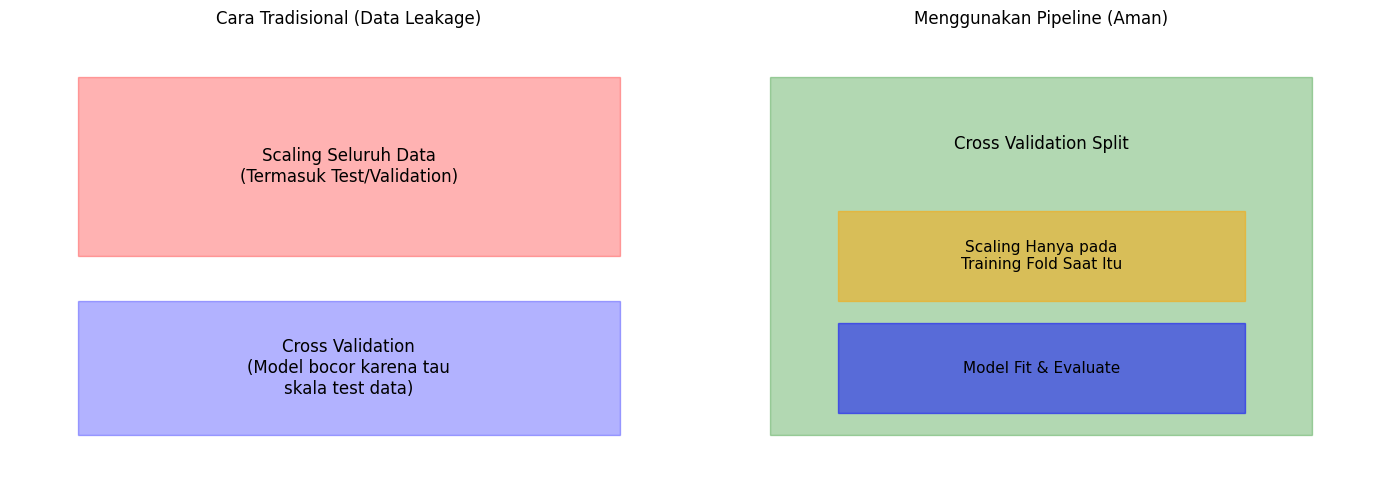

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Cara Tradisional (Salah)
axes[0].add_patch(plt.Rectangle((0.1, 0.5), 0.8, 0.4, color='red', alpha=0.3))
axes[0].text(0.5, 0.7, 'Scaling Seluruh Data\n(Termasuk Test/Validation)', ha='center', va='center', fontsize=12)
axes[0].add_patch(plt.Rectangle((0.1, 0.1), 0.8, 0.3, color='blue', alpha=0.3))
axes[0].text(0.5, 0.25, 'Cross Validation\n(Model bocor karena tau\nskala test data)', ha='center', va='center', fontsize=12)
axes[0].set_title("Cara Tradisional (Data Leakage)")
axes[0].axis('off')

# Plot Cara Pipeline (Benar)
axes[1].add_patch(plt.Rectangle((0.1, 0.1), 0.8, 0.8, color='green', alpha=0.3))
axes[1].text(0.5, 0.75, 'Cross Validation Split', ha='center', va='center', fontsize=12)
axes[1].add_patch(plt.Rectangle((0.2, 0.4), 0.6, 0.2, color='orange', alpha=0.5))
axes[1].text(0.5, 0.5, 'Scaling Hanya pada\nTraining Fold Saat Itu', ha='center', va='center', fontsize=11)
axes[1].add_patch(plt.Rectangle((0.2, 0.15), 0.6, 0.2, color='blue', alpha=0.5))
axes[1].text(0.5, 0.25, 'Model Fit & Evaluate', ha='center', va='center', fontsize=11)
axes[1].set_title("Menggunakan Pipeline (Aman)")
axes[1].axis('off')

plt.tight_layout();